Car price prediction using MLR

Files available in /content/sample_data/:
README.md
anscombe.json
CarPrice_Assignment.csv
california_housing_train.csv
mnist_train_small.csv
mnist_test.csv
california_housing_test.csv

Successfully loaded 'california_housing_train.csv':
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...    

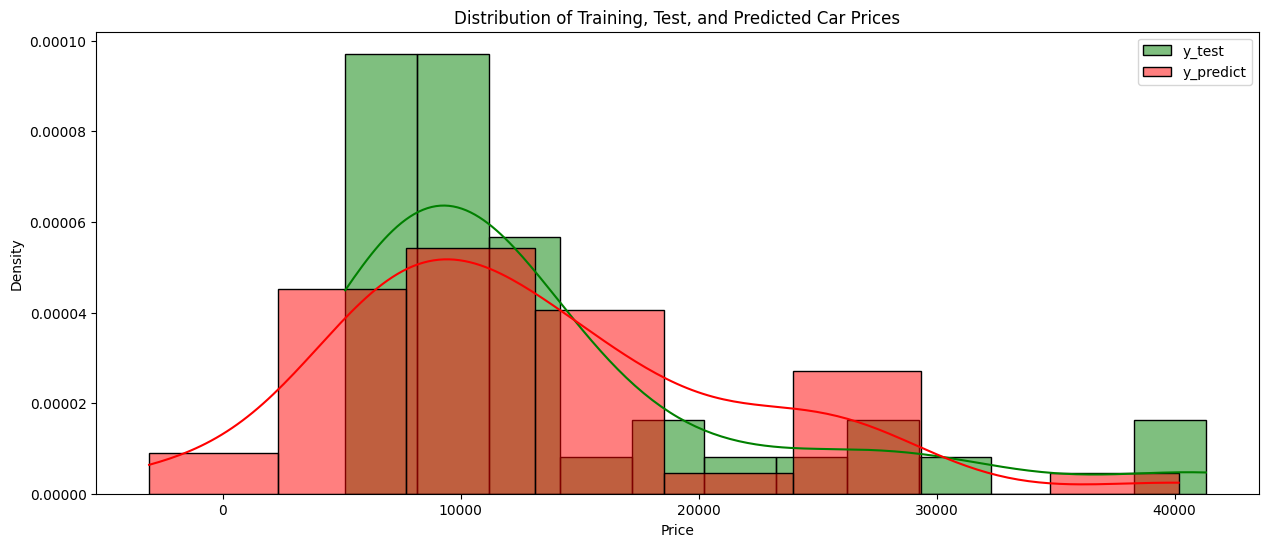

R-squared: 0.8147
Mean Absolute Error (MAE): 2701.7488
Mean Squared Error (MSE): 14628664.0363
Root Mean Squared Error (RMSE): 3824.7437


In [26]:
import pandas as pd
import os

# List files in the sample_data directory
sample_data_path = '/content/sample_data/'
print(f"Files available in {sample_data_path}:")
for filename in os.listdir(sample_data_path):
    print(filename)

# Example: Load 'california_housing_train.csv'
try:
    df = pd.read_csv(os.path.join(sample_data_path, 'CarPrice_Assignment.csv'))
    print("\nSuccessfully loaded 'california_housing_train.csv':")
    print(df.head())

except FileNotFoundError:
    print("\n'california_housing_train.csv' not found. Please check the file name or path.")
except Exception as e:
    print(f"\nAn error occurred while loading the CSV: {e}")



X = df[['wheelbase','carlength','carwidth', 'carheight',  'curbweight','enginesize','boreratio', 'stroke','compressionratio','horsepower' ,'peakrpm','citympg','highwaympg']].values


y= df['price']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



import numpy as np
# X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
# X_train_bias
def Fit():
  X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
  beta =  np.linalg.inv(X_train_bias.T.dot(X_train_bias)).dot(X_train_bias.T).dot(y_train)
  # print("beta:", beta)
  return beta



Fit()
def predict(beta,X_test):
  X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]
  y_pred = X_test_bias.dot(beta)
  # print("y_pred:", y_pred)
  return y_pred

print("y pred ",np.round(predict(Fit(),X_test)))

df1 = pd.DataFrame({'Actual': y_test, 'Predicted': np.round(predict(Fit(),X_test))})


import matplotlib.pyplot as plt
import seaborn as sns

# Calculate y_pred if not already calculated (or use df1['Predicted'])
y_pred = predict(Fit(), X_test)

plt.figure(figsize=(15, 6))

# Plotting distribution of y_train, y_test, and y_predict
#sns.histplot(y_train, color='blue', label='y_train', kde=True, stat='density', alpha=0.5)
sns.histplot(y_test, color='green', label='y_test', kde=True, stat='density', alpha=0.5)
sns.histplot(y_pred, color='red', label='y_predict', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Training, Test, and Predicted Car Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()
plt.show()


from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Ensure y_pred is calculated from the Fit() function with X_test
y_pred = predict(Fit(), X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared:.4f}")

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")



Below is to test with all indipendent datasets

In [17]:
# ── First install plotly if not already present ──
# In Colab you usually run: !pip install plotly
# But most recent Colab environments already have it

import plotly.graph_objects as go
import numpy as np

# (keep your existing meshgrid + prediction code)
# x1_grid, x2_grid, Z are already prepared

# Also keep your test points
x1 = X_test[:, 5]      # enginesize
x2 = X_test[:, 9]      # horsepower
y_actual = y_test
y_predicted = predict(Fit(), X_test)

# ── Create interactive figure ───────────────────────────────────────
fig = go.Figure()

# 1. Regression plane (surface)
fig.add_trace(
    go.Surface(
        x=x1_grid,
        y=x2_grid,
        z=Z,
        colorscale='Blues',
        opacity=0.6,
        showscale=False,
        name='Regression plane'
    )
)

# 2. Actual points
fig.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y_actual,
        mode='markers',
        marker=dict(size=6, color='blue', opacity=0.9),
        name='Actual price'
    )
)

# 3. Predicted points (optional – they should lie on the plane)
fig.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y_predicted,
        mode='markers',
        marker=dict(size=5, color='red', symbol='diamond', opacity=0.7),
        name='Predicted'
    )
)

# Layout & labels
fig.update_layout(
    title='Interactive 3D Linear Regression Plane<br>enginesize vs horsepower',
    scene=dict(
        xaxis_title='enginesize',
        yaxis_title='horsepower',
        zaxis_title='Price',
        bgcolor='rgb(245,245,245)'
    ),
    width=900,
    height=700,
    margin=dict(l=10, r=10, b=10, t=60),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

# Show the plot (interactive!)
fig.show()

y_test vs y_pred

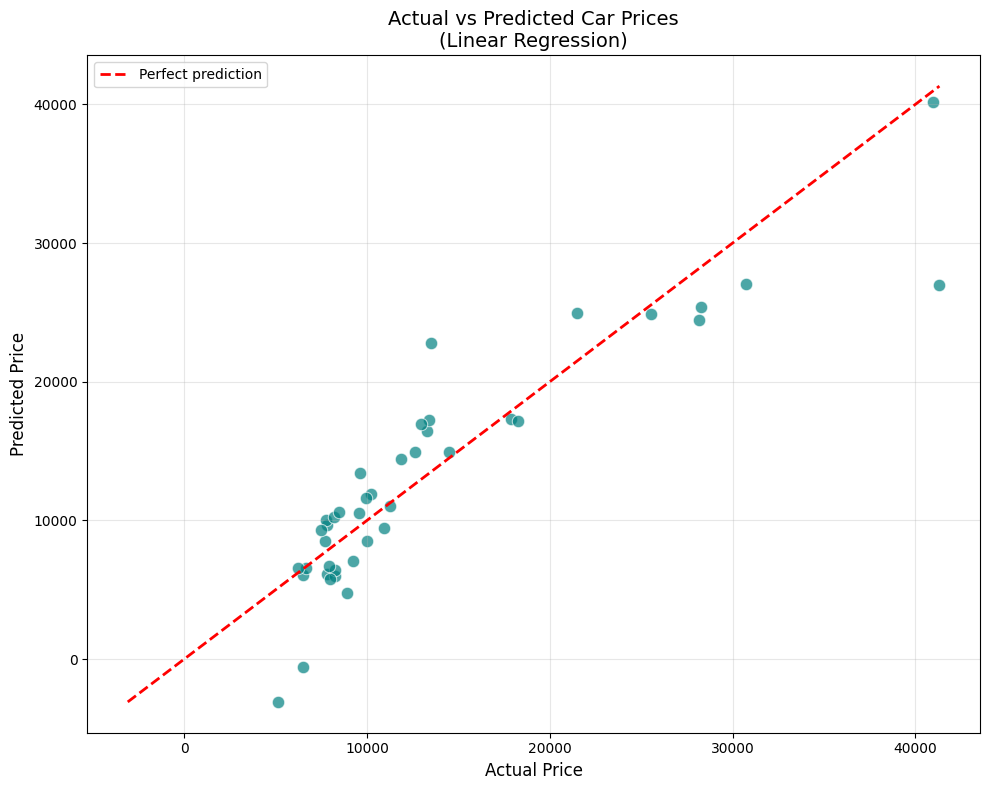

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure y_pred is from test set
y_pred = predict(Fit(), X_test)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, s=80, color='teal')

# Add perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.title('Actual vs Predicted Car Prices\n(Linear Regression)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=y_test,
        y=y_pred,
        mode='markers',
        marker=dict(size=8, color='teal', opacity=0.7),
        name='Predictions',
        text=[f"Actual: ${a:,.0f}<br>Predicted: ${p:,.0f}" for a, p in zip(y_test, y_pred)],
        hovertemplate="%{text}<extra></extra>"
    )
)

# Perfect line
fig.add_trace(
    go.Scatter(
        x=[y_test.min(), y_test.max()],
        y=[y_test.min(), y_test.max()],
        mode='lines',
        line=dict(color='red', dash='dash'),
        name='Perfect fit'
    )
)

fig.update_layout(
    title='Actual vs Predicted Car Prices (Interactive)',
    xaxis_title='Actual Price ($)',
    yaxis_title='Predicted Price ($)',
    width=900,
    height=700,
    showlegend=True,
    hovermode='closest'
)

fig.show()

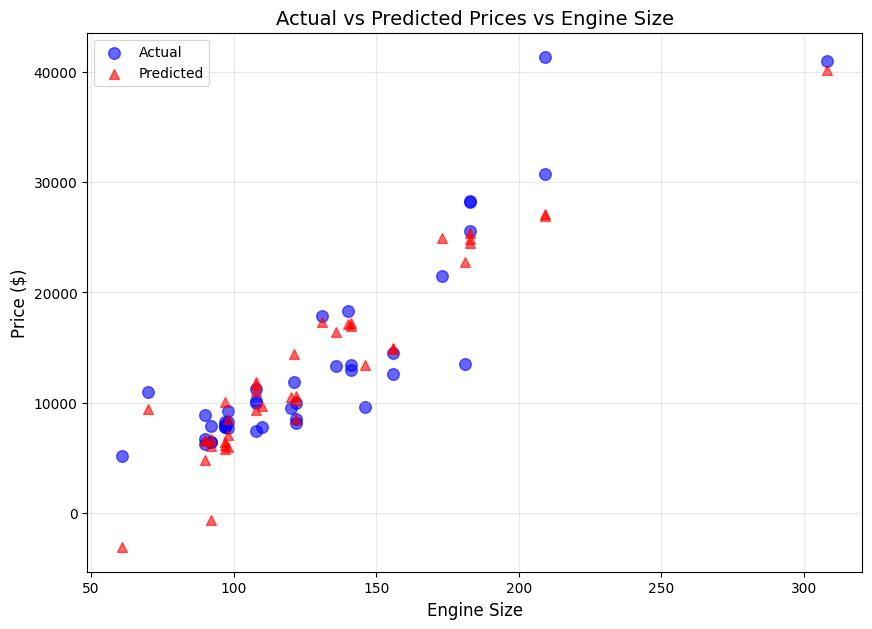

In [20]:
idx = 5  # enginesize
feature_values = X_test[:, idx]

plt.figure(figsize=(10, 7))

# Actual
plt.scatter(feature_values, y_test, color='blue', alpha=0.6, s=70, label='Actual')

# Predicted
plt.scatter(feature_values, y_pred, color='red', alpha=0.6, s=50, marker='^', label='Predicted')

plt.xlabel('Engine Size', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Actual vs Predicted Prices vs Engine Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Optimal beta values:
 [-4.89476408e+04  1.07723621e+02 -7.85044647e+01  5.58104907e+02
  1.78664877e+02  4.50994518e-01  1.23645081e+02 -3.58167959e+02
 -3.20434618e+03  3.73891372e+02  1.61534510e+01  2.61232440e+00
 -4.96427160e+02  2.35419918e+02]


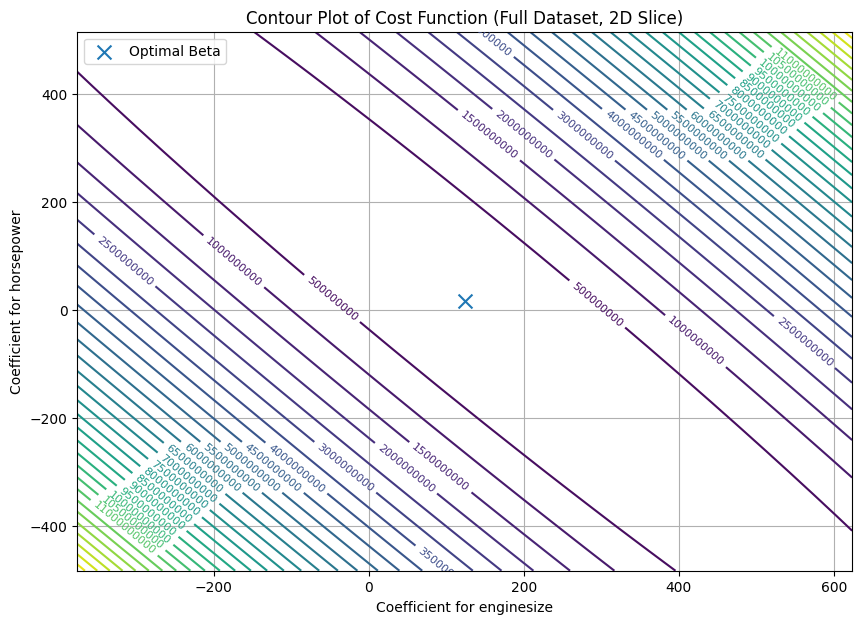

In [27]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load data
sample_data_path = '/content/sample_data/'
df = pd.read_csv(os.path.join(sample_data_path, 'CarPrice_Assignment.csv'))

# Full feature set
X = df[['wheelbase','carlength','carwidth','carheight','curbweight',
        'enginesize','boreratio','stroke','compressionratio',
        'horsepower','peakrpm','citympg','highwaympg']].values

y = df['price'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add bias term
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_bias  = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Fit model using normal equation
beta_opt = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

print("Optimal beta values:\n", beta_opt)

# Cost function
def compute_cost(beta, X, y):
    y_pred = X @ beta
    return np.mean((y - y_pred) ** 2)

# ---------------------------------------------------
# Proper contour plot for full dataset
# We vary only 2 coefficients and keep rest fixed
# Example:
#   beta for enginesize
#   beta for horsepower
# ---------------------------------------------------

feature_names = ['bias','wheelbase','carlength','carwidth','carheight','curbweight',
                 'enginesize','boreratio','stroke','compressionratio',
                 'horsepower','peakrpm','citympg','highwaympg']

# indices in beta vector
# beta[0] = bias
# beta[6] = enginesize
# beta[10] = horsepower
idx1 = 6   # enginesize
idx2 = 10  # horsepower

beta1_opt = beta_opt[idx1]
beta2_opt = beta_opt[idx2]

# Create ranges around optimal values
beta1_vals = np.linspace(beta1_opt - 500, beta1_opt + 500, 100)
beta2_vals = np.linspace(beta2_opt - 500, beta2_opt + 500, 100)

B1, B2 = np.meshgrid(beta1_vals, beta2_vals)
Z = np.zeros(B1.shape)

# Compute cost while fixing all other beta values
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        beta_temp = beta_opt.copy()
        beta_temp[idx1] = B1[i, j]
        beta_temp[idx2] = B2[i, j]
        Z[i, j] = compute_cost(beta_temp, X_train_bias, y_train)

# Plot contour
plt.figure(figsize=(10, 7))
cp = plt.contour(B1, B2, Z, levels=30)
plt.clabel(cp, inline=True, fontsize=8)

# Mark optimal point
plt.scatter(beta1_opt, beta2_opt, marker='x', s=100, label='Optimal Beta')

plt.xlabel(f"Coefficient for {feature_names[idx1]}")
plt.ylabel(f"Coefficient for {feature_names[idx2]}")
plt.title("Contour Plot of Cost Function (Full Dataset, 2D Slice)")
plt.legend()
plt.grid(True)
plt.show()

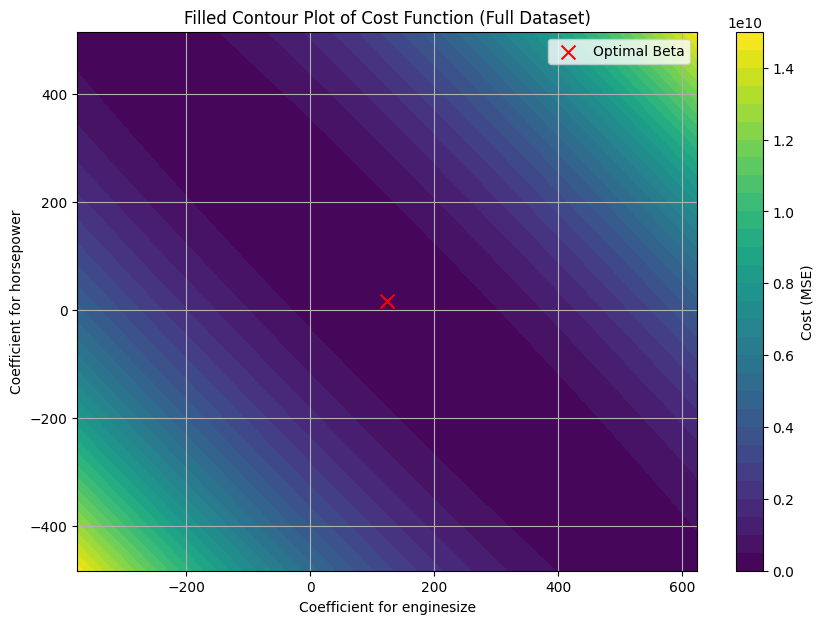

In [28]:
plt.figure(figsize=(10, 7))
cp = plt.contourf(B1, B2, Z, levels=30, cmap='viridis')
plt.colorbar(cp, label='Cost (MSE)')
plt.scatter(beta1_opt, beta2_opt, color='red', marker='x', s=100, label='Optimal Beta')
plt.xlabel(f"Coefficient for {feature_names[idx1]}")
plt.ylabel(f"Coefficient for {feature_names[idx2]}")
plt.title("Filled Contour Plot of Cost Function (Full Dataset)")
plt.legend()
plt.grid(True)
plt.show()

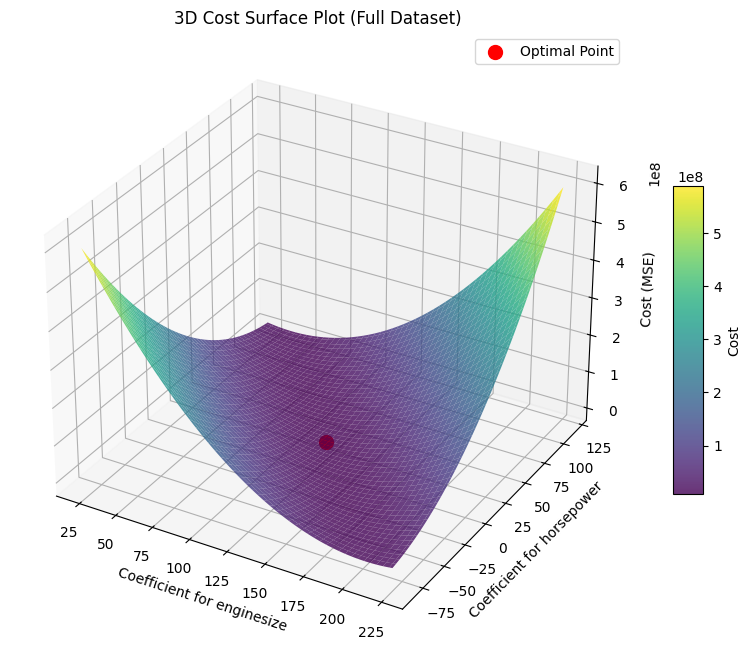

In [29]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

# Load data
sample_data_path = '/content/sample_data/'
df = pd.read_csv(os.path.join(sample_data_path, 'CarPrice_Assignment.csv'))

# Full feature set
X = df[['wheelbase','carlength','carwidth','carheight','curbweight',
        'enginesize','boreratio','stroke','compressionratio',
        'horsepower','peakrpm','citympg','highwaympg']].values

y = df['price'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add bias term
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]

# Fit model using Normal Equation
beta_opt = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

# Cost function
def compute_cost(beta, X, y):
    y_pred = X @ beta
    return np.mean((y - y_pred) ** 2)

# Feature names with beta index mapping
feature_names = ['bias','wheelbase','carlength','carwidth','carheight','curbweight',
                 'enginesize','boreratio','stroke','compressionratio',
                 'horsepower','peakrpm','citympg','highwaympg']

# Choose 2 coefficients to vary
idx1 = 6   # enginesize
idx2 = 10  # horsepower

beta1_opt = beta_opt[idx1]
beta2_opt = beta_opt[idx2]

# Create grid around optimal values
beta1_vals = np.linspace(beta1_opt - 100, beta1_opt + 100, 100)
beta2_vals = np.linspace(beta2_opt - 100, beta2_opt + 100, 100)

B1, B2 = np.meshgrid(beta1_vals, beta2_vals)
Z = np.zeros(B1.shape)

# Compute cost for each grid point
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        beta_temp = beta_opt.copy()
        beta_temp[idx1] = B1[i, j]
        beta_temp[idx2] = B2[i, j]
        Z[i, j] = compute_cost(beta_temp, X_train_bias, y_train)

# 3D Surface Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(B1, B2, Z, cmap='viridis', alpha=0.8)

# Mark optimal point
z_opt = compute_cost(beta_opt, X_train_bias, y_train)
ax.scatter(beta1_opt, beta2_opt, z_opt, color='red', s=100, label='Optimal Point')

ax.set_xlabel(f"Coefficient for {feature_names[idx1]}")
ax.set_ylabel(f"Coefficient for {feature_names[idx2]}")
ax.set_zlabel("Cost (MSE)")
ax.set_title("3D Cost Surface Plot (Full Dataset)")
ax.legend()

fig.colorbar(surf, shrink=0.5, aspect=10, label='Cost')
plt.show()